<a href="https://colab.research.google.com/github/astridmeilendra/WondrByBNI-SentimenAnalysis/blob/main/Week%204/%20BoW%20/%20BagOfWords-Analysis-of-WondrByBNIAppReviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Bag of Words (BoW) Analysis of Wondr By BNI App Reviews**

> To understand and analyze app review texts, we employ the **Bag of Words (BoW)** model. This powerful text representation technique simplifies text by treating it as an unordered 'bag' of words, focusing primarily on the **frequency of each word** rather than grammar or word order. It's a fundamental approach in **Natural Language Processing (NLP)**, commonly used for tasks like document classification and sentiment analysis. In this notebook, we'll use `CountVectorizer` from `sklearn` to convert our collection of app review texts into a **token count matrix**. Each review will then be represented as a **numerical vector**, where the values indicate the frequency of words found in our vocabulary.



## **Environment Setup and Library Imports**

In [ ]:
# Install required libraries
!pip install Sastrawi textblob wordcloud

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import save_npz
from wordcloud import WordCloud
from textblob import TextBlob
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11


## **Data Loading and Preprocessing**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/PBA/Dataset Tugas 1/df_wondrRev.csv')

# Setup stopwords & stemmer
stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

# Clean text function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stopwords]
    return " ".join(words)

df['final_text'] = df['content'].apply(clean_text)
df[['content','final_text']].head(10)

Mounted at /content/drive


,content,final_text
0,Bagus dan sangat membantu,bagus sangat bantu
1,baik,baik
2,mudah dan simpel,mudah simpel
3,bagus,bagus
4,"lebih mudah, dan praktis",lebih mudah praktis
5,pencatatan aktivitas transaksi gak selalu upda...,catat aktivitas transaksi gak selalu update re...
6,saya melakukan transfer uang sebesar 500.000 s...,laku transfer uang besar saldo potong bni curi...
7,sangat terbantu,sangat bantu
8,bagus,bagus
9,tolong tambahin fitur mobile tunai yang setor ...,tambahin fitur mobile tunai setor tunai soal m...


## **Sentiment Analysis and Feature Engineering**

In [ ]:
# Create sentiment labels from score
def label_sentiment(score):
    if score in [1,2]:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['score'].apply(label_sentiment)

# Polarity & subjectivity with TextBlob
df['sentiment_polarity'] = df['final_text'].astype(str).apply(lambda x: TextBlob(x).polarity)
df['sentiment_subjectivity'] = df['final_text'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

df[['content','final_text','score','sentiment','sentiment_polarity','sentiment_subjectivity']].head(10)


,content,final_text,score,sentiment,sentiment_polarity,sentiment_subjectivity
0,Bagus dan sangat membantu,bagus sangat bantu,5,positive,0.0,0.0
1,baik,baik,5,positive,0.0,0.0
2,mudah dan simpel,mudah simpel,5,positive,0.0,0.0
3,bagus,bagus,4,positive,0.0,0.0
4,"lebih mudah, dan praktis",lebih mudah praktis,5,positive,0.0,0.0
5,pencatatan aktivitas transaksi gak selalu upda...,catat aktivitas transaksi gak selalu update re...,2,negative,0.0,0.0
6,saya melakukan transfer uang sebesar 500.000 s...,laku transfer uang besar saldo potong bni curi...,1,negative,0.0,0.0
7,sangat terbantu,sangat bantu,5,positive,0.0,0.0
8,bagus,bagus,5,positive,0.0,0.0
9,tolong tambahin fitur mobile tunai yang setor ...,tambahin fitur mobile tunai setor tunai soal m...,5,positive,0.0,0.0


In [ ]:
# Initialize CountVectorizer
bow_vectorizer = CountVectorizer(
    analyzer='word',
    token_pattern=r'\b\w+\b',
    min_df=2,
    max_df=0.95
)

# Fit and transform
bow_matrix = bow_vectorizer.fit_transform(df['final_text'])

print(f'BoW Matrix Shape : {bow_matrix.shape}')
print(f'Vocabulary size  : {len(bow_vectorizer.get_feature_names_out())}')

BoW Matrix Shape : (89454, 7605)
Vocabulary size  : 7605


## **Bag of Words (BoW) Visualization**

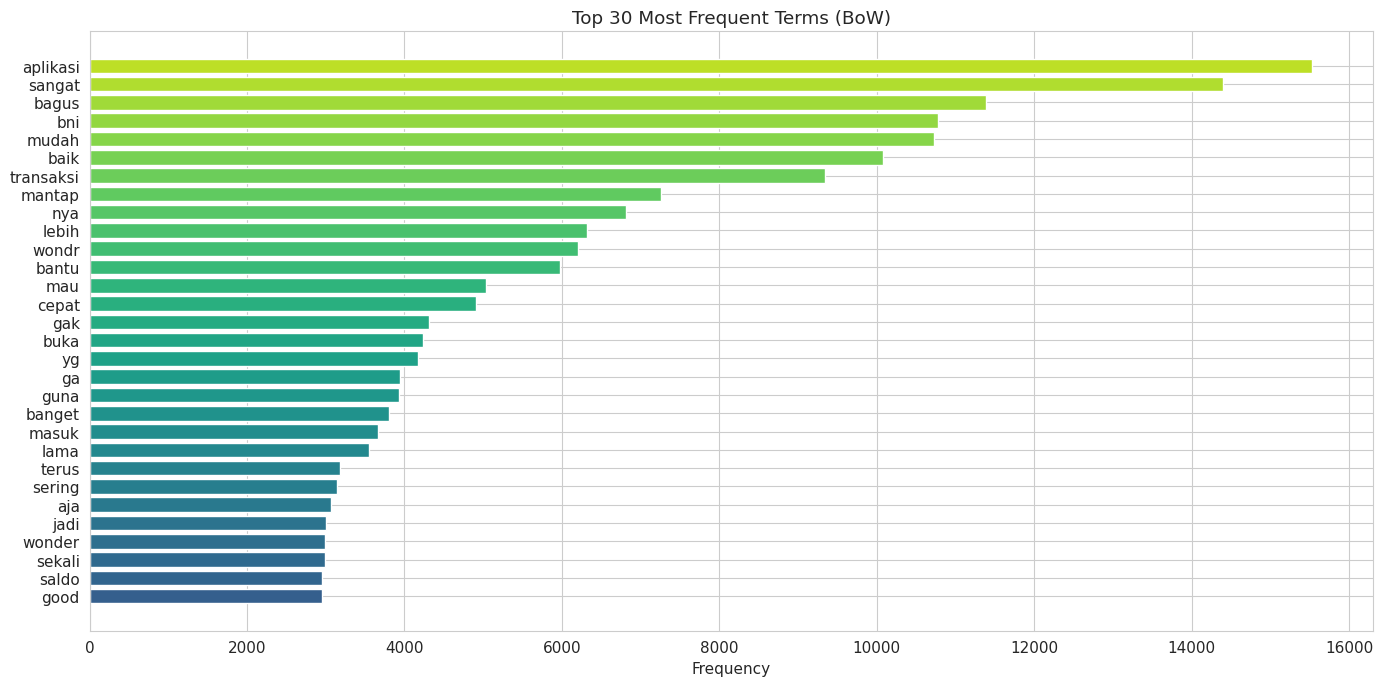

In [ ]:
# Term frequencies
vocab = bow_vectorizer.get_feature_names_out()
term_freq = np.asarray(bow_matrix.sum(axis=0)).flatten()
df_freq = pd.DataFrame({'term': vocab, 'frequency': term_freq}).sort_values('frequency', ascending=False)

# Top 30 bar chart
top_n = 30
top_terms = df_freq.head(top_n)

plt.figure(figsize=(14,7))
plt.barh(top_terms['term'][::-1], top_terms['frequency'][::-1], color=plt.cm.viridis(np.linspace(0.3,0.9,top_n)))
plt.xlabel('Frequency')
plt.title('Top 30 Most Frequent Terms (BoW)')
plt.tight_layout()
plt.show()

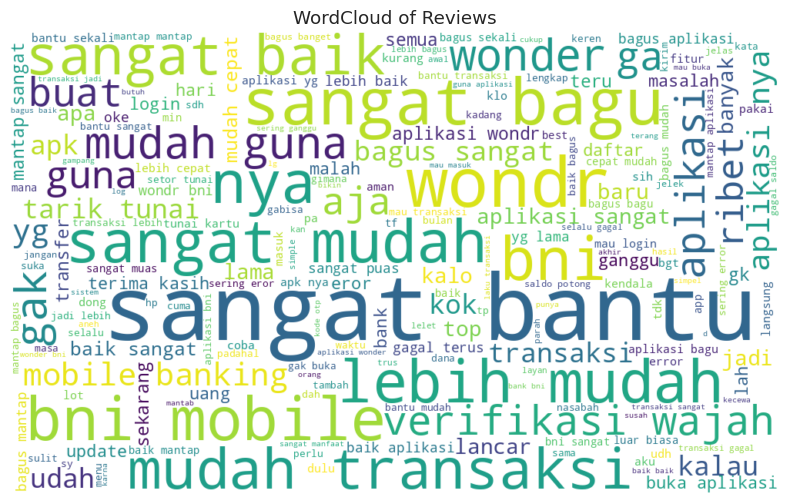

In [ ]:
# WordCloud
wordcloud = WordCloud(width=1000, height=600, background_color='white').generate(' '.join(df['final_text']))
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud of Reviews")
plt.show()

### **Regex-based Sentiment Signal Extraction**

In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported for array operations, though it's usually imported with matplotlib

# Define regex patterns based on common Indonesian review words
positive_patterns = [
    r'\b(bagus|mantap|keren|puas|suka|lancar|cepat|mudah|nyaman|aman|praktis|simpel)\b',
    r'\b(terima\s*kasih|terimakasih|makasih)\b',
    r'\b(membantu|berguna|bermanfaat)\b',
]

negative_patterns = [
    r'\b(error|gagal|bug|lemot|lambat|lama|hang|crash)\b',
    r'\b(kecewa|buruk|jelek|parah|busuk|sampah|benci|ribet|susah)\b',
    r'\b(tidak\s*bisa|gak\s*bisa|gabisa|ga\s*bisa|tdk\s*bisa)\b',
    r'\b(hilang|kehilangan|potong|potongan)\s*(saldo|uang|dana)\b',
]

Regex-based sentiment signals:
  Reviews with positive signals : 39,682 (44.4 %)
  Reviews with negative signals : 16,884 (18.9 %)
  Total positive matches        : 50,486
  Total negative matches        : 23,843


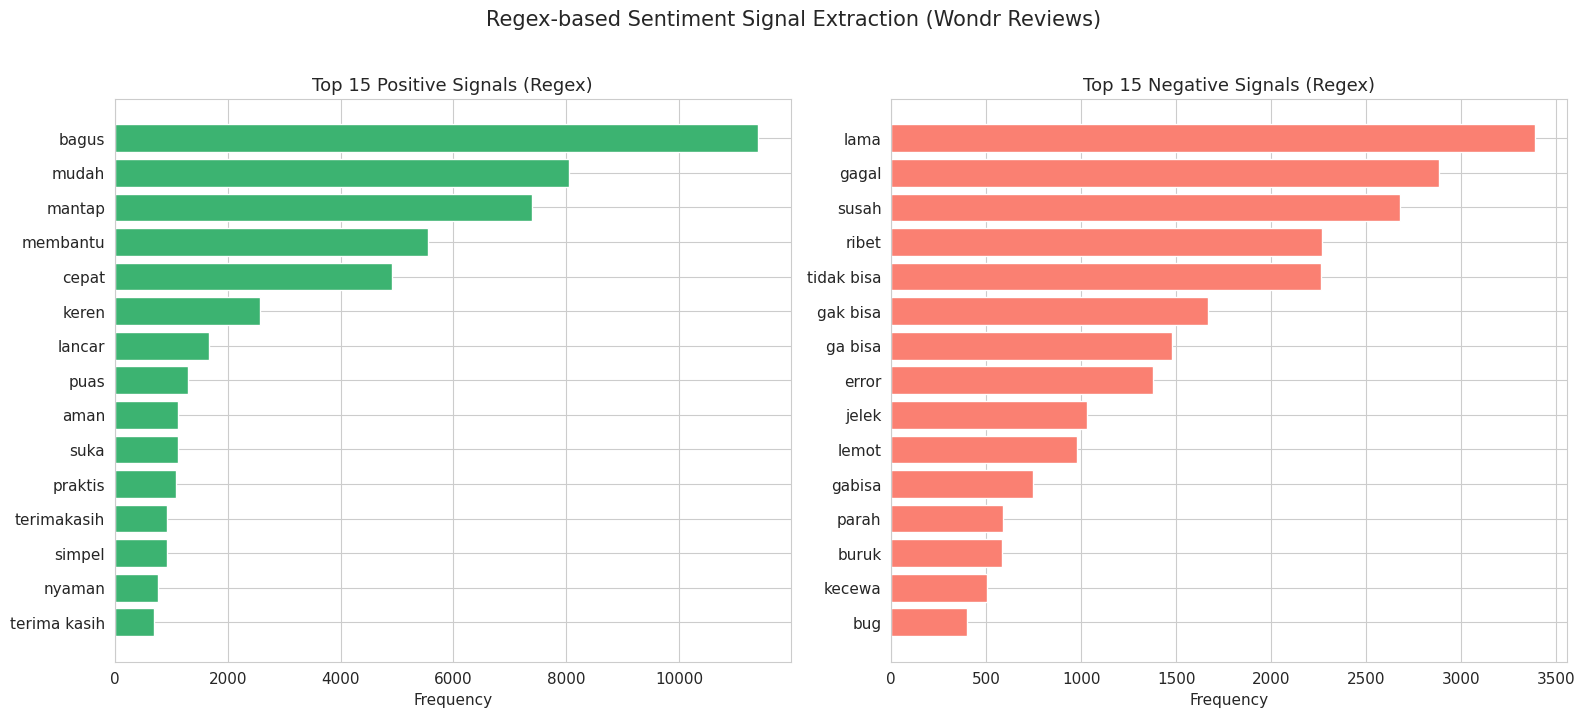

In [ ]:
# Compile regex
pos_regex = re.compile('|'.join(positive_patterns), re.IGNORECASE)
neg_regex = re.compile('|'.join(negative_patterns), re.IGNORECASE)

# Apply regex to content column
df['pos_matches'] = df['content'].astype(str).apply(lambda x: pos_regex.findall(x.lower()))
df['neg_matches'] = df['content'].astype(str).apply(lambda x: neg_regex.findall(x.lower()))
df['pos_count'] = df['pos_matches'].apply(len)
df['neg_count'] = df['neg_matches'].apply(len)

# Summary
total_pos = df['pos_count'].sum()
total_neg = df['neg_count'].sum()
reviews_with_pos = (df['pos_count'] > 0).sum()
reviews_with_neg = (df['neg_count'] > 0).sum()

print("Regex-based sentiment signals:")
print(f"  Reviews with positive signals : {reviews_with_pos:,} ({reviews_with_pos/len(df)*100:.1f} %)")
print(f"  Reviews with negative signals : {reviews_with_neg:,} ({reviews_with_neg/len(df)*100:.1f} %)")
print(f"  Total positive matches        : {total_pos:,}")
print(f"  Total negative matches        : {total_neg:,}")

# Top 15 positive/negative signals
# Corrected extraction to handle tuples from findall with capturing groups
all_pos = [word_part for matches_list in df['pos_matches'] for match_tuple in matches_list for word_part in match_tuple if word_part]
all_neg = [word_part for matches_list in df['neg_matches'] for match_tuple in matches_list for word_part in match_tuple if word_part]

pos_counter = Counter(all_pos).most_common(15)
neg_counter = Counter(all_neg).most_common(15)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

if pos_counter:
    words_p, counts_p = zip(*pos_counter)
    # Ensure color and edgecolor are explicitly lists of the correct length
    num_bars_p = len(words_p)
    colors_p = ['mediumseagreen'] * num_bars_p
    edgecolors_p = ['white'] * num_bars_p
    axes[0].barh(words_p[::-1], counts_p[::-1], color=colors_p[::-1], edgecolor=edgecolors_p[::-1])
    axes[0].set_title('Top 15 Positive Signals (Regex)', fontsize=13)
    axes[0].set_xlabel('Frequency')

if neg_counter:
    words_n, counts_n = zip(*neg_counter)
    # Ensure color and edgecolor are explicitly lists of the correct length
    num_bars_n = len(words_n)
    colors_n = ['salmon'] * num_bars_n
    edgecolors_n = ['white'] * num_bars_n
    axes[1].barh(words_n[::-1], counts_n[::-1], color=colors_n[::-1], edgecolor=edgecolors_n[::-1])
    axes[1].set_title('Top 15 Negative Signals (Regex)', fontsize=13)
    axes[1].set_xlabel('Frequency')

plt.suptitle('Regex-based Sentiment Signal Extraction (Wondr Reviews)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Save BoW matrix
save_npz('bow_matrix.npz', bow_matrix)

# Save vocabulary
pd.DataFrame({'term': vocab}).to_csv('/content/drive/MyDrive/PBA/Dataset Tugas 1/bow_vocabulary.csv', index=False)

# Save term frequencies
df_freq.to_csv('/content/drive/MyDrive/PBA/Dataset Tugas 1/bow_term_frequencies.csv', index=False)

# Save vectorizer
with open('bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vectorizer, f)

print("Artifacts exported successfully.")

Artifacts exported successfully.
